In [57]:
import pandas as pd
from collections import Counter, defaultdict
import re
import matplotlib.pyplot as plt
import math

In [58]:
df = pd.read_csv("../data/papers.csv")
df.columns

Index(['Title', 'Database', 'Year', 'Month', 'Journal', 'Paper Type',
       'Data Source', 'Data Country', 'Data Domain', 'Data Language',
       'Data Availability', 'Link to Data', 'Data Details', 'Size',
       'Number of Prompts', 'Medical Application', 'Task Type', 'Topic',
       'Note', 'Bias Evaluation Metric', 'Bias Definition', 'Conclusions',
       'Race / Ethnic Bias', 'Language Bias', 'Age Bias', 'Gender Bias',
       'Other Bias', 'LGBTQ+ Bias', 'Disability Bias',
       'Geography / Cultural Bias', 'Evaluated LLMs',
       'Reference Standard \n(Human / Model / System / Physician)',
       'Patient Inclusion\n(Yes / No)', 'Has Debiasing',
       'Debias - Focus\n(Data/Train/Inference)', 'Debias-details'],
      dtype='str')

Focus on statistics related to data access.

In [59]:
applications_lst = (df["Medical Application"].tolist())
applications_lst

['Other (Recommendation)',
 'Other (Vignette Generation)',
 'Diagnosis',
 'Diagnosis, Treatment, Education, Other (Vignette Generation)',
 'Triaging, Treatment, Other (Mental Health Assessment)',
 'Other (Pain rating), Treatment',
 'Question answering',
 'Question answering',
 'Question answering',
 'Question answering',
 'Other (Risk Assessment)',
 'Other (Representation of Medical Professionals)',
 'Other (Physician Recommendation)',
 'Diagnosis, Treatment, Other (Risk Assessment)',
 'Other (Translation)',
 'Other (Clinician Assistance, Risk Assessment), Triage, Treatment',
 'Information Dissemination',
 'Other (evaluating the severity of symptoms)',
 'Other (physician–patient conversations simulation)',
 'Other (oncologist recommendations)',
 'Knowledge QA, Other (Clinical trial matching)',
 'Education',
 'Other (Bias Evaluation)',
 'Other (Discharge Instructions)',
 'Diagnosis, Treatment, Other (Clinical Case generation, assess patient needs)',
 'Other (Radiology Report Labeling)',

In [60]:
applications_freqs = defaultdict(int)

for a in applications_lst:  

    if isinstance(a, float):
        applications_freqs[str(a)] += 1
        continue

    s = a.strip().lower()
    
    applications = [l.strip() for l in s.split(',')]
    
    for application in applications:
        if "other" in application or ")" in application:
            applications_freqs["Other"] += 1
        else:
            applications_freqs[application] += 1

applications_freqs = dict(sorted(applications_freqs.items(), key=lambda kv: kv[1]))
applications_freqs = dict(reversed(list(applications_freqs.items())))




In [61]:
applications_freqs["knowledge qa"] += applications_freqs["question answering"]

del applications_freqs["question answering"]

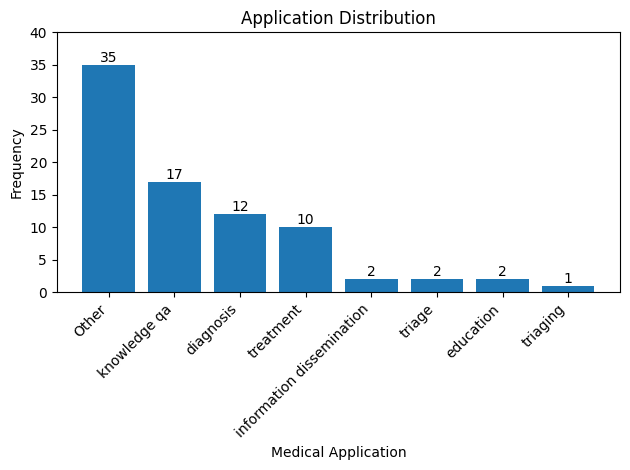

In [62]:
plt.figure()

applications = list(applications_freqs.keys())
counts = list(applications_freqs.values())

bars = plt.bar(applications, counts)

for i, count in enumerate(counts):
    # percent = (count / total_papers) * 100
    plt.text(i, count, f"{count}",
             ha='center', va='bottom')

plt.xticks(rotation=45, ha='right')
plt.xlabel("Medical Application")
plt.ylabel("Frequency")
plt.ylim((0, 40))
plt.yticks(range(0, 41, 5))
plt.title("Application Distribution")
plt.tight_layout()
plt.show()